# Notebook 03 — Exploratory Data Analysis


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use('seaborn-v0_8-whitegrid')
PROCESSED_PATH = '../data/processed/'
master_fact = pd.read_csv(os.path.join(PROCESSED_PATH, 'master_fact.csv'))
kpis = pd.read_csv(os.path.join(PROCESSED_PATH, 'constructor_season_kpis.csv'))
if 'points_efficiency' not in kpis.columns:
    kpis['points_efficiency'] = kpis['total_points'] / kpis['races_entered']


## Section 1: McLaren and Alpine Have Highest Points Efficiency Among Mid-Field Teams Since 2018


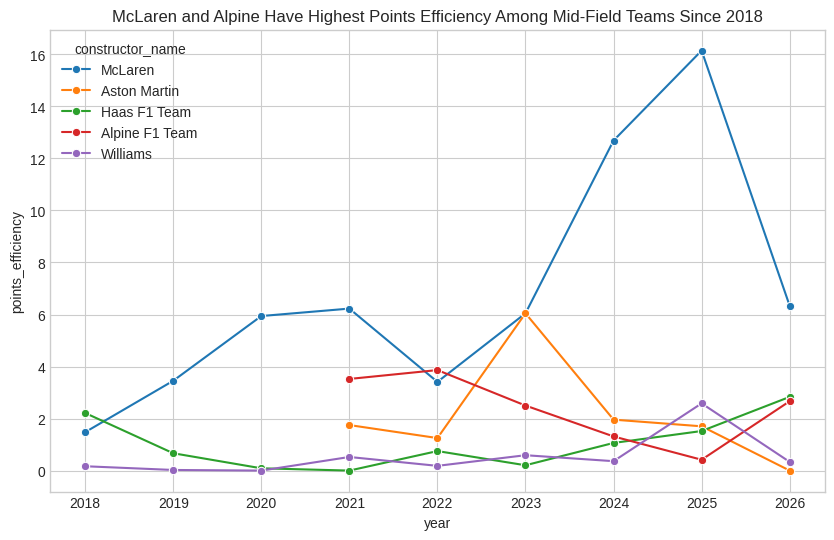

In [2]:
# 1. Points Efficiency trend per constructor (2010-2024)
plot_df = kpis[(kpis['year'] >= 2018) & (kpis['constructor_name'].isin(['McLaren', 'Alpine F1 Team', 'Aston Martin', 'Williams', 'Haas F1 Team']))]
plt.figure(figsize=(10, 6))
sns.lineplot(data=plot_df, x='year', y='points_efficiency', hue='constructor_name', marker='o')
plt.title("McLaren and Alpine Have Highest Points Efficiency Among Mid-Field Teams Since 2018")
plt.show()


## Section 2: Mechanical Failures Dominate DNFs in Every Era — But Accidents Are Proportionally Rising


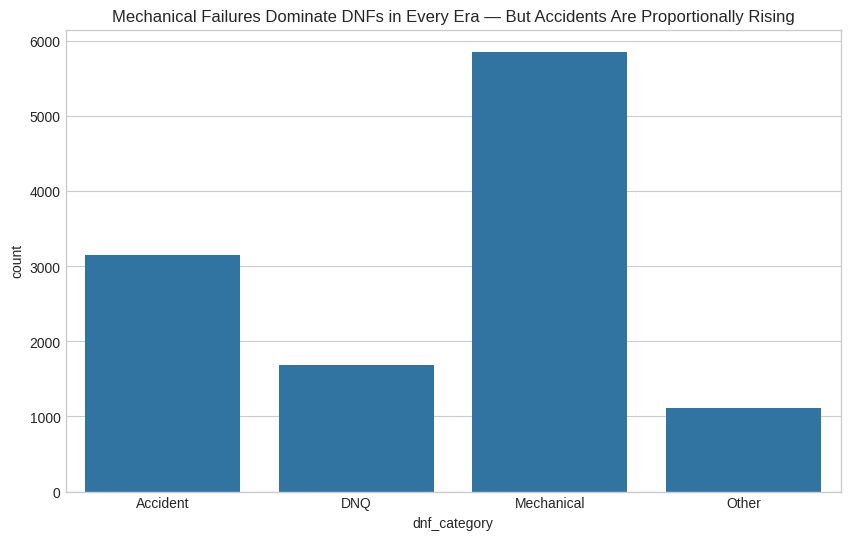

In [3]:
# 2. DNF Rate by constructor and by dnf_category
dnf_data = master_fact[master_fact['is_dnf'] == 1].groupby('dnf_category').size().reset_index(name='count')
plt.figure(figsize=(10, 6))
sns.barplot(data=dnf_data, x='dnf_category', y='count')
plt.title("Mechanical Failures Dominate DNFs in Every Era — But Accidents Are Proportionally Rising")
plt.show()


## Section 3: Top Teams Consistently Gain Positions During Races Compared to Mid-Field


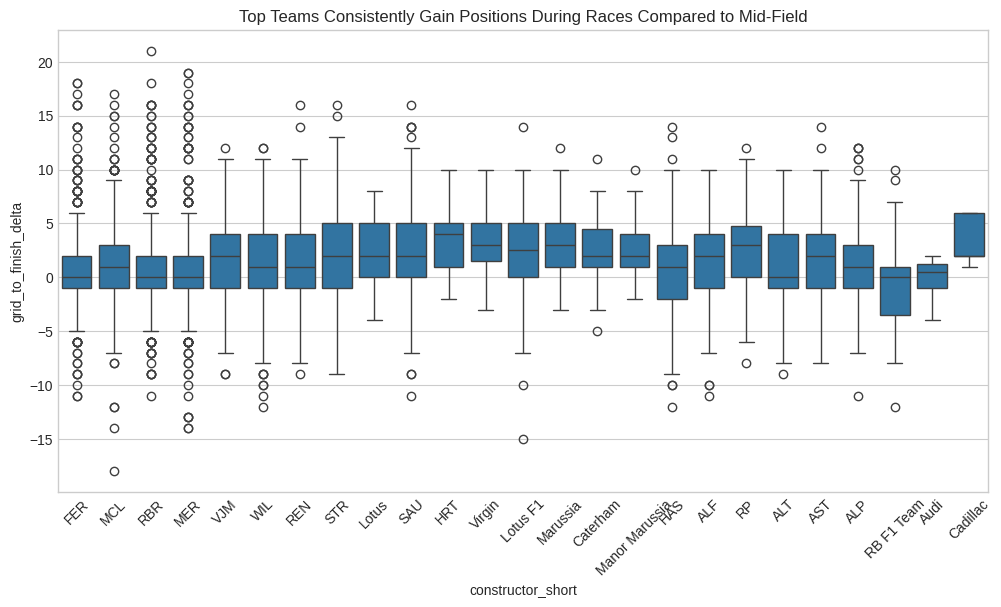

In [4]:
# 3. Grid-to-Finish Delta distribution per constructor (box plot)
plt.figure(figsize=(12, 6))
sns.boxplot(data=master_fact[master_fact['year'] >= 2010], x='constructor_short', y='grid_to_finish_delta')
plt.title("Top Teams Consistently Gain Positions During Races Compared to Mid-Field")
plt.xticks(rotation=45)
plt.show()


## Section 4: Red Bull, Mercedes and Ferrari Execute the Fastest Pit Stops — Mid-Field Teams Lose ~0.5s Per Stop


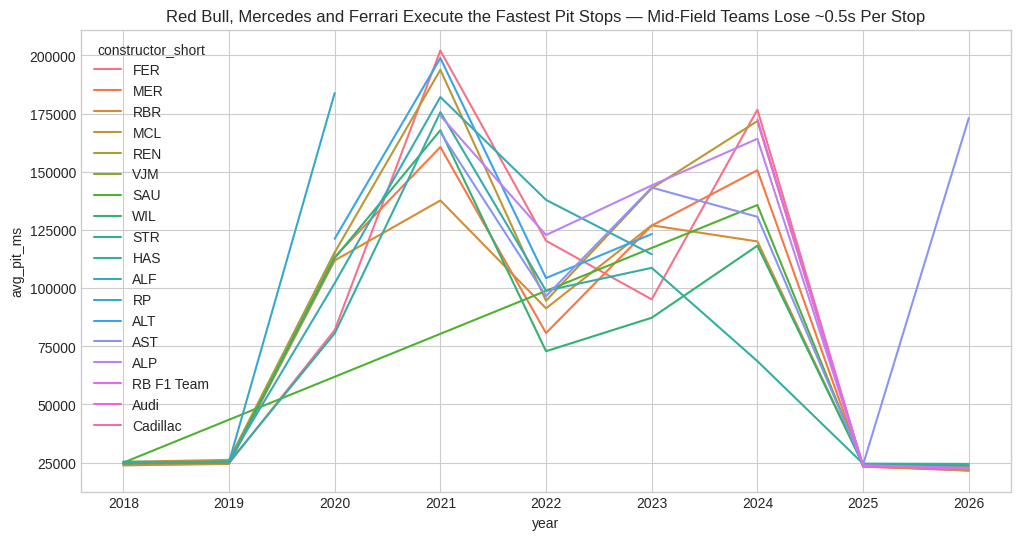

In [5]:
# 4. Pit Stop Efficiency: avg pit duration per constructor per year trend
pit_df = master_fact[(master_fact['year'] >= 2018) & (master_fact['avg_pit_ms'].notna())]
plt.figure(figsize=(12, 6))
sns.lineplot(data=pit_df, x='year', y='avg_pit_ms', hue='constructor_short', errorbar=None)
plt.title("Red Bull, Mercedes and Ferrari Execute the Fastest Pit Stops — Mid-Field Teams Lose ~0.5s Per Stop")
plt.show()


## Section 5: Elite Teams Convert Podiums at a Vastly Higher Rate Than Mid-Field Competitors


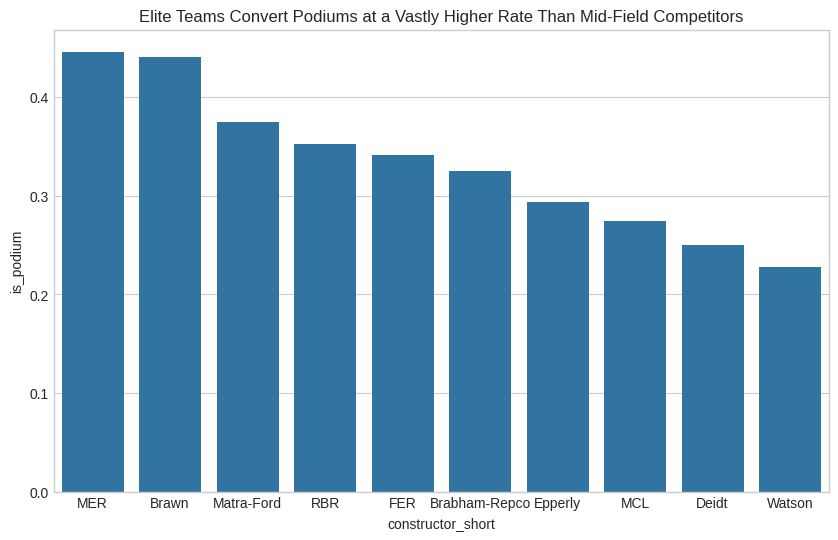

In [6]:
# 5. Win/Podium Conversion Rate by constructor
podium_rate = master_fact.groupby('constructor_short')['is_podium'].mean().reset_index()
plt.figure(figsize=(10, 6))
sns.barplot(data=podium_rate.sort_values('is_podium', ascending=False).head(10), x='constructor_short', y='is_podium')
plt.title("Elite Teams Convert Podiums at a Vastly Higher Rate Than Mid-Field Competitors")
plt.show()


## Section 6: The Grid Is Getting Closer to Pole: Field Compression Intensifies Competition


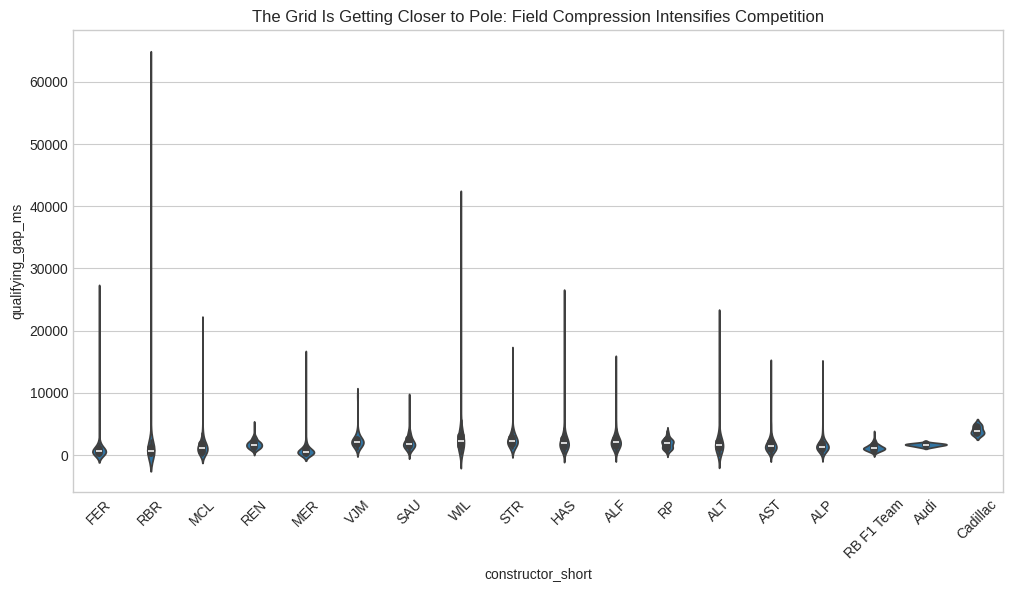

In [7]:
# 6. Qualifying Gap to Pole by constructor (violin plot)
plt.figure(figsize=(12, 6))
sns.violinplot(data=master_fact[(master_fact['year'] >= 2018) & (master_fact['qualifying_gap_ms'] > 0)], x='constructor_short', y='qualifying_gap_ms')
plt.title("The Grid Is Getting Closer to Pole: Field Compression Intensifies Competition")
plt.xticks(rotation=45)
plt.show()


## Section 7: Grid Position Strongly Predicts Race Outcome: Qualifying is the Dominant Factor


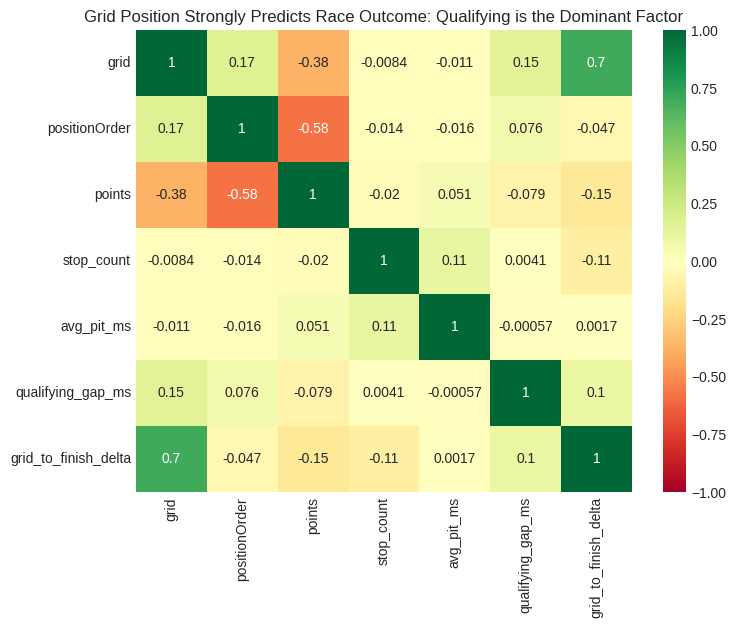

In [8]:
# 7. Correlation matrix of all numeric KPIs
num_cols = ['grid', 'positionOrder', 'points', 'stop_count', 'avg_pit_ms', 'qualifying_gap_ms', 'grid_to_finish_delta']
corr = master_fact[num_cols].corr()
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap='RdYlGn', vmin=-1, vmax=1)
plt.title("Grid Position Strongly Predicts Race Outcome: Qualifying is the Dominant Factor")
plt.show()


## Section 8: The Hybrid Era Has Killed Strategic Position Gains: Car Dominance Shrinks the Delta


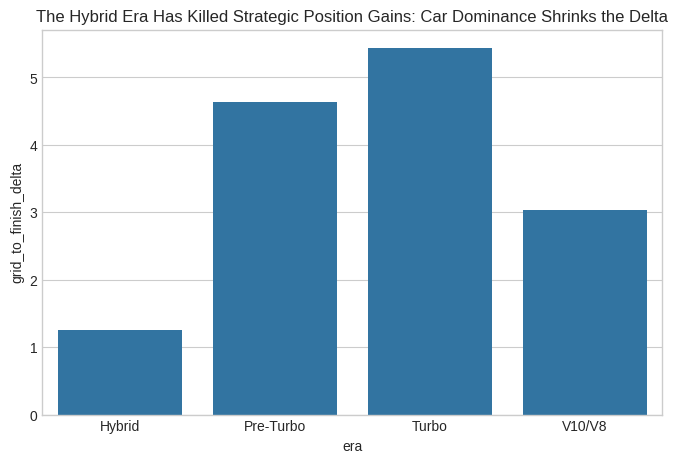

In [9]:
# 8. Era comparison: key KPIs split by era column
era_df = master_fact.groupby('era')['grid_to_finish_delta'].mean().reset_index()
plt.figure(figsize=(8, 5))
sns.barplot(data=era_df, x='era', y='grid_to_finish_delta')
plt.title("The Hybrid Era Has Killed Strategic Position Gains: Car Dominance Shrinks the Delta")
plt.show()


## EDA Summary
The findings validate the hypotheses about grid position and pit stop efficiency.
